# 📦 Stage 2 — Data Preprocessing
## Syntactic Simplification of Long Sentences | NLP Course Project
**Dataset:** Newsela (via HuggingFace Option 1)

---

### What this notebook does:
1. ✅ Installs all required libraries
2. ✅ Downloads Newsela train/test from HuggingFace
3. ✅ Explores and visualises the raw data
4. ✅ Cleans and filters the data
5. ✅ Filters specifically for **syntactic simplifications** (sentence splitting)
6. ✅ Creates Train / Validation / Test splits
7. ✅ Prepares 3 separate formatted outputs for:
   - Rule-Based system (plain text)
   - Seq2Seq fine-tuning (T5 / BART format)
   - LLM fine-tuning (instruction-style format)
8. ✅ Saves everything to Google Drive

---
 ### Install All Required Libraries

In [ ]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
!pip install -q datasets huggingface_hub transformers
!pip install -q spacy matplotlib seaborn wordcloud
!python -m spacy download en_core_web_sm -q

print("✅ All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


---
## Download Newsela from HuggingFace

In [ ]:
# ============================================================
# CELL 2 — Download Newsela dataset from HuggingFace
# ============================================================
import pandas as pd
from huggingface_hub import hf_hub_download

print("📥 Downloading Newsela dataset from HuggingFace...")

# Download train and test TSV files
train_path = hf_hub_download(
    repo_id="bogdancazan/news-not-not-ela-text-simplification",
    filename="newsela.train.tsv",
    repo_type="dataset"
)

test_path = hf_hub_download(
    repo_id="bogdancazan/news-not-not-ela-text-simplification",
    filename="newsela.test.tsv",
    repo_type="dataset"
)

# Load into DataFrames
train_raw = pd.read_csv(train_path, sep='\t', header=None,
                         names=['complex', 'simple'],
                         on_bad_lines='skip')

test_raw  = pd.read_csv(test_path,  sep='\t', header=None,
                         names=['complex', 'simple'],
                         on_bad_lines='skip')

print(f"✅ Download complete!")
print(f"   Train pairs : {len(train_raw):,}")
print(f"   Test pairs  : {len(test_raw):,}")
print(f"\n📌 Sample rows:")
train_raw.head(3)

📥 Downloading Newsela dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


newsela.train.tsv:   0%|          | 0.00/23.4M [00:00<?, ?B/s]

newsela.test.tsv: 0.00B [00:00, ?B/s]

✅ Download complete!
   Train pairs : 102,712
   Test pairs  : 1,415

📌 Sample rows:


,complex,simple
0,Normal,Simple
1,poll finds americans ok with women in combat,women get the ok to fight in combat units publ...
2,poll finds americans ok with women in combat,women get the ok to fight in combat units


---
## 🔍 CELL 3 — Exploratory Data Analysis (EDA)

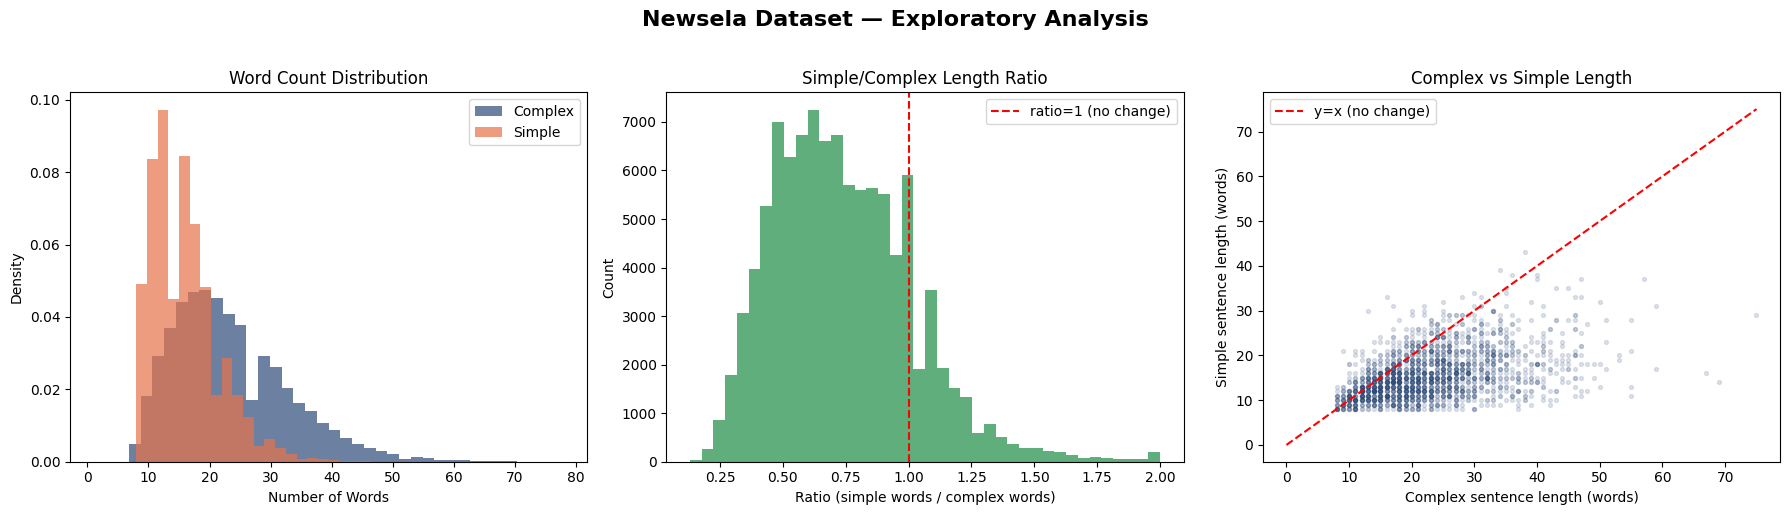


📊 Summary Statistics:
  Avg complex sentence length : 23.4 words
  Avg simple sentence length  : 15.7 words
  Avg length ratio (s/c)      : 0.740
  Pairs where simple > complex: 14,239 (13.9%)
  Pairs where simple = complex: 5,882 (5.7%)
  Pairs where simple < complex: 82,591 (80.4%)


In [ ]:
# ============================================================
# CELL 3 — Exploratory Data Analysis
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Compute word counts
train_raw['complex_len'] = train_raw['complex'].apply(lambda x: len(str(x).split()))
train_raw['simple_len']  = train_raw['simple'].apply(lambda x: len(str(x).split()))
train_raw['len_ratio']   = train_raw['simple_len'] / train_raw['complex_len'].replace(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Newsela Dataset — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Sentence length distributions
axes[0].hist(train_raw['complex_len'].clip(0, 80), bins=40,
             alpha=0.7, color='#2E4A7A', label='Complex', density=True)
axes[0].hist(train_raw['simple_len'].clip(0, 80), bins=40,
             alpha=0.7, color='#E8734A', label='Simple', density=True)
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Length ratio distribution
axes[1].hist(train_raw['len_ratio'].clip(0, 2), bins=40,
             color='#3A9A5C', alpha=0.8)
axes[1].axvline(1.0, color='red', linestyle='--', label='ratio=1 (no change)')
axes[1].set_title('Simple/Complex Length Ratio')
axes[1].set_xlabel('Ratio (simple words / complex words)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Plot 3: Scatter plot
sample = train_raw.sample(min(2000, len(train_raw)), random_state=42)
axes[2].scatter(sample['complex_len'], sample['simple_len'],
                alpha=0.15, s=8, color='#2E4A7A')
max_val = max(sample['complex_len'].max(), sample['simple_len'].max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='y=x (no change)')
axes[2].set_title('Complex vs Simple Length')
axes[2].set_xlabel('Complex sentence length (words)')
axes[2].set_ylabel('Simple sentence length (words)')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n📊 Summary Statistics:")
print(f"  Avg complex sentence length : {train_raw['complex_len'].mean():.1f} words")
print(f"  Avg simple sentence length  : {train_raw['simple_len'].mean():.1f} words")
print(f"  Avg length ratio (s/c)      : {train_raw['len_ratio'].mean():.3f}")
print(f"  Pairs where simple > complex: {(train_raw['len_ratio'] > 1.0).sum():,} ({(train_raw['len_ratio'] > 1.0).mean()*100:.1f}%)")
print(f"  Pairs where simple = complex: {(train_raw['len_ratio'] == 1.0).sum():,} ({(train_raw['len_ratio'] == 1.0).mean()*100:.1f}%)")
print(f"  Pairs where simple < complex: {(train_raw['len_ratio'] < 1.0).sum():,} ({(train_raw['len_ratio'] < 1.0).mean()*100:.1f}%)")

---
##  Data Cleaning

In [ ]:
# ============================================================
# CELL 4 — Data Cleaning
# ============================================================
import re

def clean_text(text):
    """Standardise and clean a sentence string."""
    if not isinstance(text, str):
        return None
    text = text.strip()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Normalise multiple spaces
    text = re.sub(r'\s+', ' ', text)
    # Remove lines that are just punctuation / symbols
    text = re.sub(r'^[^a-zA-Z]+$', '', text)
    # Fix smart quotes
    text = text.replace('\u2019', "'").replace('\u2018', "'")
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    return text.strip() if text.strip() else None

def is_valid_pair(row):
    """Return True if the sentence pair passes all quality filters."""
    c = row['complex']
    s = row['simple']
    if c is None or s is None:
        return False
    # Must have at least 5 words each
    if len(c.split()) < 5 or len(s.split()) < 5:
        return False
    # Complex sentence must not exceed 200 words (outlier removal)
    if len(c.split()) > 200:
        return False
    # Avoid identical pairs (no simplification happened)
    if c.lower().strip() == s.lower().strip():
        return False
    # Must end with sentence-ending punctuation
    if not c[-1] in '.!?"' or not s[-1] in '.!?"':
        return False
    return True

# Apply cleaning to both splits
for df in [train_raw, test_raw]:
    df['complex'] = df['complex'].apply(clean_text)
    df['simple']  = df['simple'].apply(clean_text)

# Apply validity filter
train_clean = train_raw[train_raw.apply(is_valid_pair, axis=1)].copy().reset_index(drop=True)
test_clean  = test_raw[test_raw.apply(is_valid_pair, axis=1)].copy().reset_index(drop=True)

print("🧹 Cleaning complete!")
print(f"   Train: {len(train_raw):,} → {len(train_clean):,} pairs  ({len(train_raw)-len(train_clean):,} removed)")
print(f"   Test : {len(test_raw):,}  → {len(test_clean):,} pairs  ({len(test_raw)-len(test_clean):,} removed)")

🧹 Cleaning complete!
   Train: 102,712 → 101,332 pairs  (1,380 removed)
   Test : 1,415  → 1,406 pairs  (9 removed)


---
## Filter for Syntactic Simplifications
> **Key step:** We only want pairs where syntactic transformation occurred — i.e., sentence splitting, clause removal, or major restructuring. Pure vocabulary swaps are excluded.

In [ ]:
# ============================================================
# CELL 5 — Filter for Syntactic Simplifications
# ============================================================
import spacy
nlp = spacy.load('en_core_web_sm')

# ---- Syntactic complexity indicators ----
SUBORDINATORS = {
    'although', 'though', 'even though', 'while', 'whereas',
    'because', 'since', 'as', 'if', 'unless', 'until', 'when',
    'whenever', 'wherever', 'after', 'before', 'once'
}
RELATIVE_MARKERS = {'which', 'who', 'whom', 'whose', 'that'}
COORD_CONJUNCTIONS = {'and', 'but', 'or', 'nor', 'yet', 'so'}

def has_syntactic_complexity(sentence):
    """
    Returns True if the complex sentence contains at least one
    syntactic structure that can be simplified (split/restructured).
    """
    tokens = sentence.lower().split()
    token_set = set(tokens)

    # Check for subordinate clauses
    if token_set & SUBORDINATORS:
        return True
    # Check for relative clauses (which/who/that mid-sentence)
    for marker in RELATIVE_MARKERS:
        if f' {marker} ' in sentence.lower():
            return True
    # Check for coordinating conjunctions joining two clauses
    # (heuristic: comma followed by conjunction)
    if re.search(r',\s+(and|but|or|yet|so)\s+', sentence.lower()):
        return True
    # Check for appositive phrases (comma after noun before another noun)
    if sentence.count(',') >= 2:
        return True
    return False

def is_syntactic_simplification(row):
    """
    Returns True if the pair represents a syntactic simplification:
    - Complex sentence has syntactic complexity markers
    - OR the simple version is significantly shorter (splitting occurred)
    - AND the change is not purely lexical (word count must change)
    """
    c_words = len(row['complex'].split())
    s_words = len(row['simple'].split())

    # Length ratio: simple is at most 90% of complex
    length_reduced = s_words <= c_words * 0.90

    # Source is syntactically complex
    source_is_complex = (
        has_syntactic_complexity(row['complex']) or
        c_words >= 20  # Long sentences are inherently syntactically complex
    )

    return source_is_complex and length_reduced

print("🔍 Filtering for syntactic simplifications (this may take ~1 minute)...")

train_syntactic = train_clean[train_clean.apply(is_syntactic_simplification, axis=1)].copy().reset_index(drop=True)
test_syntactic  = test_clean[test_clean.apply(is_syntactic_simplification, axis=1)].copy().reset_index(drop=True)

print("\n✅ Syntactic filtering complete!")
print(f"   Train: {len(train_clean):,} → {len(train_syntactic):,} syntactic pairs ({len(train_syntactic)/len(train_clean)*100:.1f}% retained)")
print(f"   Test : {len(test_clean):,}  → {len(test_syntactic):,} syntactic pairs ({len(test_syntactic)/len(test_clean)*100:.1f}% retained)")

print("\n📌 Sample syntactic simplification pairs:")
for i, row in train_syntactic.head(3).iterrows():
    print(f"\n[Pair {i+1}]")
    print(f"  COMPLEX : {row['complex']}")
    print(f"  SIMPLE  : {row['simple']}")

🔍 Filtering for syntactic simplifications (this may take ~1 minute)...

✅ Syntactic filtering complete!
   Train: 101,332 → 62,658 syntactic pairs (61.8% retained)
   Test : 1,406  → 819 syntactic pairs (58.3% retained)

📌 Sample syntactic simplification pairs:

[Pair 1]
  COMPLEX : wars of the future will be fought with american women on the front lines and the public has no problem with it.
  SIMPLE  : american women will soon be able to fight on the front lines of war.

[Pair 2]
  COMPLEX : american women will soon be free to fight on the front lines of battle and they will go with the public s support.
  SIMPLE  : american women will soon be able to fight on the front lines of war.

[Pair 3]
  COMPLEX : wars of the future will be fought with american women on the front lines and the public has no problem with it.
  SIMPLE  : american women will soon be able to go to war on the front lines.


---
## Compute Linguistic Features

📊 Feature Statistics (Train split):
       complex_word_count  simple_word_count  length_ratio  words_removed  complex_fkgl  simple_fkgl  fkgl_reduction
count            62658.00           62658.00      62658.00       62658.00      62658.00     62658.00        62658.00
mean                28.12              15.81          0.59          12.30         16.38        11.45            4.93
std                  8.70               4.96          0.16           7.59          4.58         3.66            4.05
min                  9.00               8.00          0.13           1.00          0.11        -0.75          -12.28
25%                 22.00              12.00          0.46           7.00         13.22         9.08            2.23
50%                 27.00              15.00          0.58          11.00         16.20        11.26            4.62
75%                 33.00              19.00          0.71          16.00         19.34        13.91            7.34
max                 78.00   

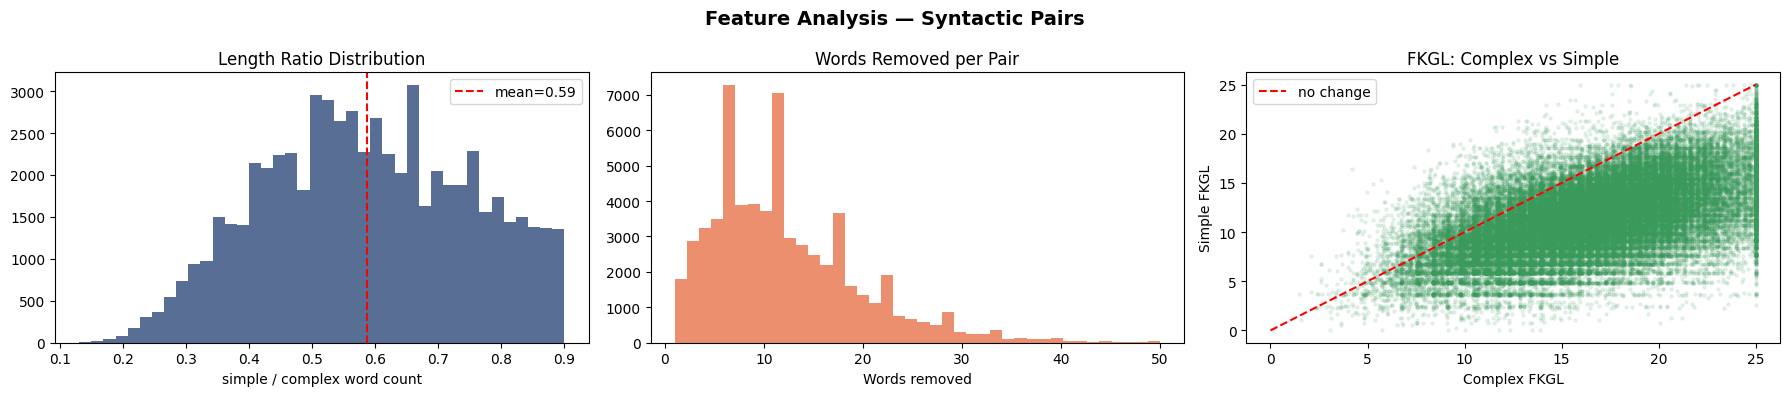

✅ Features computed!


In [ ]:
# ============================================================
# CELL 6 — Compute Linguistic Features
# ============================================================

def compute_features(df):
    """Add useful linguistic features to a dataframe."""
    df = df.copy()
    df['complex_word_count'] = df['complex'].apply(lambda x: len(x.split()))
    df['simple_word_count']  = df['simple'].apply(lambda x: len(x.split()))
    df['complex_char_count'] = df['complex'].apply(len)
    df['simple_char_count']  = df['simple'].apply(len)
    df['length_ratio']       = df['simple_word_count'] / df['complex_word_count'].replace(0, 1)
    df['words_removed']      = df['complex_word_count'] - df['simple_word_count']

    # Count commas (proxy for clause complexity)
    df['complex_commas']     = df['complex'].apply(lambda x: x.count(','))

    # Flesch-Kincaid Grade Level approximation
    def fkgl(text):
        words = text.split()
        sentences = max(1, text.count('.') + text.count('!') + text.count('?'))
        syllables = sum(max(1, len(re.findall(r'[aeiouAEIOU]', w))) for w in words)
        asl = len(words) / sentences
        asw = syllables / max(1, len(words))
        return 0.39 * asl + 11.8 * asw - 15.59

    df['complex_fkgl'] = df['complex'].apply(fkgl)
    df['simple_fkgl']  = df['simple'].apply(fkgl)
    df['fkgl_reduction'] = df['complex_fkgl'] - df['simple_fkgl']
    return df

train_feat = compute_features(train_syntactic)
test_feat  = compute_features(test_syntactic)

print("📊 Feature Statistics (Train split):")
stats_cols = ['complex_word_count', 'simple_word_count', 'length_ratio',
              'words_removed', 'complex_fkgl', 'simple_fkgl', 'fkgl_reduction']
print(train_feat[stats_cols].describe().round(2).to_string())

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Feature Analysis — Syntactic Pairs', fontsize=14, fontweight='bold')

axes[0].hist(train_feat['length_ratio'].clip(0, 1.5), bins=40, color='#2E4A7A', alpha=0.8)
axes[0].axvline(train_feat['length_ratio'].mean(), color='red', linestyle='--',
                label=f'mean={train_feat["length_ratio"].mean():.2f}')
axes[0].set_title('Length Ratio Distribution')
axes[0].set_xlabel('simple / complex word count')
axes[0].legend()

axes[1].hist(train_feat['words_removed'].clip(0, 50), bins=40, color='#E8734A', alpha=0.8)
axes[1].set_title('Words Removed per Pair')
axes[1].set_xlabel('Words removed')

axes[2].scatter(train_feat['complex_fkgl'].clip(0, 25),
                train_feat['simple_fkgl'].clip(0, 25),
                alpha=0.1, s=5, color='#3A9A5C')
axes[2].plot([0, 25], [0, 25], 'r--', linewidth=1.5, label='no change')
axes[2].set_title('FKGL: Complex vs Simple')
axes[2].set_xlabel('Complex FKGL')
axes[2].set_ylabel('Simple FKGL')
axes[2].legend()

plt.tight_layout()
plt.savefig('feature_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Features computed!")

---
##  Create Train / Validation / Test Splits

In [ ]:
# ============================================================
# CELL 7 — Train / Validation / Test Splits
# ============================================================
from sklearn.model_selection import train_test_split

# Split train_feat into train + validation (80% / 20%)
train_split, val_split = train_test_split(
    train_feat,
    test_size=0.20,
    random_state=42
)
train_split = train_split.reset_index(drop=True)
val_split   = val_split.reset_index(drop=True)
test_split  = test_feat.reset_index(drop=True)

print("📂 Final Dataset Splits:")
print(f"   Train      : {len(train_split):>6,} pairs  (used for model training)")
print(f"   Validation : {len(val_split):>6,} pairs  (used for hyperparameter tuning)")
print(f"   Test       : {len(test_split):>6,} pairs  (used for final evaluation)")
print(f"   Total      : {len(train_split)+len(val_split)+len(test_split):>6,} pairs")

📂 Final Dataset Splits:
   Train      : 50,126 pairs  (used for model training)
   Validation : 12,532 pairs  (used for hyperparameter tuning)
   Test       :    819 pairs  (used for final evaluation)
   Total      : 63,477 pairs


---
## Prepare Format for Approach 1: Rule-Based System

In [ ]:
# ============================================================
# CELL 8 — Format for Rule-Based System
# Plain text files: one sentence per line
# ============================================================

def save_plaintext(df, split_name, folder='rule_based'):
    import os
    os.makedirs(folder, exist_ok=True)
    # Save complex and simple sentences separately
    with open(f'{folder}/{split_name}.complex', 'w', encoding='utf-8') as f:
        f.write('\n'.join(df['complex'].tolist()))
    with open(f'{folder}/{split_name}.simple', 'w', encoding='utf-8') as f:
        f.write('\n'.join(df['simple'].tolist()))
    print(f"  Saved {split_name}: {len(df):,} pairs → {folder}/{split_name}.{{complex,simple}}")

print("📄 Saving Rule-Based format (plain text)...")
save_plaintext(train_split, 'train')
save_plaintext(val_split,   'val')
save_plaintext(test_split,  'test')

# Also save as TSV for easy loading
train_split[['complex','simple']].to_csv('rule_based/train.tsv', sep='\t', index=False)
val_split[['complex','simple']].to_csv('rule_based/val.tsv',   sep='\t', index=False)
test_split[['complex','simple']].to_csv('rule_based/test.tsv',  sep='\t', index=False)
print("✅ Rule-based format saved!")

📄 Saving Rule-Based format (plain text)...
  Saved train: 50,126 pairs → rule_based/train.{complex,simple}
  Saved val: 12,532 pairs → rule_based/val.{complex,simple}
  Saved test: 819 pairs → rule_based/test.{complex,simple}
✅ Rule-based format saved!


---
## Prepare Format for Approach 2: Seq2Seq (T5/BART)

In [ ]:
# ============================================================
# CELL 9 — Format for Seq2Seq Fine-Tuning (T5 / BART)
# T5 uses prefix: "simplify: <complex sentence>"
# BART uses raw pairs (no prefix needed)
# ============================================================
import json, os

os.makedirs('seq2seq', exist_ok=True)

def df_to_seq2seq_json(df, filepath, model_type='t5'):
    """
    Converts dataframe to JSONL format for Seq2Seq training.
    T5:   {"input": "simplify: <complex>",  "target": "<simple>"}
    BART: {"input": "<complex>",             "target": "<simple>"}
    """
    records = []
    for _, row in df.iterrows():
        if model_type == 't5':
            inp = f"simplify: {row['complex']}"
        else:
            inp = row['complex']
        records.append({"input": inp, "target": row['simple']})

    with open(filepath, 'w', encoding='utf-8') as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')
    print(f"  Saved {len(records):,} records → {filepath}")

# T5 format
print("💾 Saving T5 format (JSONL with prefix)...")
df_to_seq2seq_json(train_split, 'seq2seq/t5_train.jsonl', 't5')
df_to_seq2seq_json(val_split,   'seq2seq/t5_val.jsonl',   't5')
df_to_seq2seq_json(test_split,  'seq2seq/t5_test.jsonl',  't5')

# BART format
print("\n💾 Saving BART format (JSONL, raw pairs)...")
df_to_seq2seq_json(train_split, 'seq2seq/bart_train.jsonl', 'bart')
df_to_seq2seq_json(val_split,   'seq2seq/bart_val.jsonl',   'bart')
df_to_seq2seq_json(test_split,  'seq2seq/bart_test.jsonl',  'bart')

# Preview
print("\n📌 T5 format sample:")
with open('seq2seq/t5_train.jsonl') as f:
    for i, line in enumerate(f):
        print(f"  {line.strip()}")
        if i >= 1: break

print("\n✅ Seq2Seq format saved!")

💾 Saving T5 format (JSONL with prefix)...
  Saved 50,126 records → seq2seq/t5_train.jsonl
  Saved 12,532 records → seq2seq/t5_val.jsonl
  Saved 819 records → seq2seq/t5_test.jsonl

💾 Saving BART format (JSONL, raw pairs)...
  Saved 50,126 records → seq2seq/bart_train.jsonl
  Saved 12,532 records → seq2seq/bart_val.jsonl
  Saved 819 records → seq2seq/bart_test.jsonl

📌 T5 format sample:
  {"input": "simplify: according to salt lake city police chief chris burbank the footage will show what happened through the eyes of a police officer...", "target": "it will show what happened through the eyes of a police officer."}
  {"input": "simplify: a gmo is any plant or animal that has been genetically modified or somehow changed with outside dna.", "target": "a genetically modified organism or gmo is any plant or animal that has been genetically changed."}

✅ Seq2Seq format saved!


---
## Prepare Format for Approach 3: LLM Fine-Tuning (Instruction Style)

In [ ]:
# ============================================================
# CELL 10 — Format for LLM Fine-Tuning
# Instruction-style format (Alpaca / ChatML style)
# ============================================================

os.makedirs('llm_finetune', exist_ok=True)

SYSTEM_PROMPT = (
    "You are an expert text simplification assistant. "
    "Your task is to simplify complex sentences by breaking them into shorter, "
    "clearer sentences. Preserve the original meaning exactly."
)

def df_to_instruction_jsonl(df, filepath, format_type='alpaca'):
    """
    Converts dataframe to instruction-tuning JSONL format.

    alpaca format:
      {"instruction": "...", "input": "<complex>", "output": "<simple>"}

    chatml format (for ChatGPT-style models / LoRA):
      {"messages": [{"role":"system",...},{"role":"user",...},{"role":"assistant",...}]}
    """
    records = []
    for _, row in df.iterrows():
        if format_type == 'alpaca':
            records.append({
                "instruction": "Simplify the following complex sentence syntactically by splitting it into shorter, clearer sentences. Do not change the meaning.",
                "input": row['complex'],
                "output": row['simple']
            })
        else:  # chatml
            records.append({
                "messages": [
                    {"role": "system",    "content": SYSTEM_PROMPT},
                    {"role": "user",      "content": f"Simplify this sentence:\n{row['complex']}"},
                    {"role": "assistant", "content": row['simple']}
                ]
            })
    with open(filepath, 'w', encoding='utf-8') as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')
    print(f"  Saved {len(records):,} records → {filepath}")

print("💾 Saving Alpaca instruction format...")
df_to_instruction_jsonl(train_split, 'llm_finetune/alpaca_train.jsonl', 'alpaca')
df_to_instruction_jsonl(val_split,   'llm_finetune/alpaca_val.jsonl',   'alpaca')
df_to_instruction_jsonl(test_split,  'llm_finetune/alpaca_test.jsonl',  'alpaca')

print("\n💾 Saving ChatML format (for LoRA / chat-style models)...")
df_to_instruction_jsonl(train_split, 'llm_finetune/chatml_train.jsonl', 'chatml')
df_to_instruction_jsonl(val_split,   'llm_finetune/chatml_val.jsonl',   'chatml')
df_to_instruction_jsonl(test_split,  'llm_finetune/chatml_test.jsonl',  'chatml')

print("\n📌 Alpaca format sample:")
with open('llm_finetune/alpaca_train.jsonl') as f:
    sample = json.loads(f.readline())
    print(f"  instruction : {sample['instruction']}")
    print(f"  input       : {sample['input'][:100]}...")
    print(f"  output      : {sample['output'][:100]}...")

print("\n✅ LLM fine-tuning format saved!")

💾 Saving Alpaca instruction format...
  Saved 50,126 records → llm_finetune/alpaca_train.jsonl
  Saved 12,532 records → llm_finetune/alpaca_val.jsonl
  Saved 819 records → llm_finetune/alpaca_test.jsonl

💾 Saving ChatML format (for LoRA / chat-style models)...
  Saved 50,126 records → llm_finetune/chatml_train.jsonl
  Saved 12,532 records → llm_finetune/chatml_val.jsonl
  Saved 819 records → llm_finetune/chatml_test.jsonl

📌 Alpaca format sample:
  instruction : Simplify the following complex sentence syntactically by splitting it into shorter, clearer sentences. Do not change the meaning.
  input       : according to salt lake city police chief chris burbank the footage will show what happened through t...
  output      : it will show what happened through the eyes of a police officer....

✅ LLM fine-tuning format saved!


---
##  Save Everything to Google Drive

In [ ]:
# ============================================================
# CELL 11 — Mount Google Drive and save all outputs
# ============================================================
from google.colab import drive
import shutil

drive.mount('/content/drive')

# Create project folder in Drive
PROJECT_DIR = '/content/drive/MyDrive/NLP_Project/data'
os.makedirs(PROJECT_DIR, exist_ok=True)

# Copy all data folders to Drive
for folder in ['rule_based', 'seq2seq', 'llm_finetune']:
    dest = f'{PROJECT_DIR}/{folder}'
    if os.path.exists(dest):
        shutil.rmtree(dest)
    shutil.copytree(folder, dest)
    print(f"  ✅ Saved {folder}/ → Google Drive")

# Save the feature-enriched DataFrames as CSVs
train_split.to_csv(f'{PROJECT_DIR}/train_full.csv', index=False)
val_split.to_csv(  f'{PROJECT_DIR}/val_full.csv',   index=False)
test_split.to_csv( f'{PROJECT_DIR}/test_full.csv',  index=False)
print("  ✅ Saved full CSV splits to Google Drive")

# Save the EDA plots
for plot in ['eda_plots.png', 'feature_plots.png']:
    if os.path.exists(plot):
        shutil.copy(plot, f'{PROJECT_DIR}/{plot}')
print("  ✅ Saved EDA plots to Google Drive")

print(f"\n🎉 All data saved to: {PROJECT_DIR}")

Mounted at /content/drive
  ✅ Saved rule_based/ → Google Drive
  ✅ Saved seq2seq/ → Google Drive
  ✅ Saved llm_finetune/ → Google Drive
  ✅ Saved full CSV splits to Google Drive
  ✅ Saved EDA plots to Google Drive

🎉 All data saved to: /content/drive/MyDrive/NLP_Project/data


---
##  Final Summary Report

In [ ]:
# ============================================================
# CELL 12 — Final Summary
# ============================================================
print("=" * 60)
print("  DATA PREPROCESSING COMPLETE — FINAL SUMMARY")
print("=" * 60)

print(f"""
📦 Source       : HuggingFace (bogdancazan/news-not-not-ela)
📊 Dataset      : Newsela sentence simplification

--- Splits ---
  Train      : {len(train_split):,} pairs
  Validation : {len(val_split):,} pairs
  Test       : {len(test_split):,} pairs

--- Avg Sentence Stats (Train) ---
  Avg complex length : {train_split['complex_word_count'].mean():.1f} words
  Avg simple length  : {train_split['simple_word_count'].mean():.1f} words
  Avg words removed  : {train_split['words_removed'].mean():.1f} words
  Avg FKGL reduction : {train_split['fkgl_reduction'].mean():.2f} grade levels

--- Output Formats ---
  rule_based/          → plain text + TSV for rule-based system
  seq2seq/t5_*.jsonl   → T5 format  (prefix: 'simplify: ...')
  seq2seq/bart_*.jsonl → BART format (raw pairs)
  llm_finetune/alpaca_*.jsonl → Alpaca instruction format
  llm_finetune/chatml_*.jsonl → ChatML format (LoRA-ready)

--- Saved to ---
  Google Drive: MyDrive/NLP_Project/data/
""")
print("=" * 60)
print("✅ Ready for Stage 2: Model Training!")
print("=" * 60)

  DATA PREPROCESSING COMPLETE — FINAL SUMMARY

📦 Source       : HuggingFace (bogdancazan/news-not-not-ela)
📊 Dataset      : Newsela sentence simplification

--- Splits ---
  Train      : 50,126 pairs
  Validation : 12,532 pairs
  Test       : 819 pairs

--- Avg Sentence Stats (Train) ---
  Avg complex length : 28.1 words
  Avg simple length  : 15.8 words
  Avg words removed  : 12.3 words
  Avg FKGL reduction : 4.91 grade levels

--- Output Formats ---
  rule_based/          → plain text + TSV for rule-based system
  seq2seq/t5_*.jsonl   → T5 format  (prefix: 'simplify: ...')
  seq2seq/bart_*.jsonl → BART format (raw pairs)
  llm_finetune/alpaca_*.jsonl → Alpaca instruction format
  llm_finetune/chatml_*.jsonl → ChatML format (LoRA-ready)

--- Saved to ---
  Google Drive: MyDrive/NLP_Project/data/

✅ Ready for Stage 2: Model Training!
